# Preprocesssing

In [ ]:
import pandas as pd
import numpy as np
import os
import json
import kagglehub
import warnings
import traceback
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from sklearn.model_selection import RepeatedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

import itertools
import random

# Load preprocessing classes
os.chdir('../')  # Change to project root directory
# Preprocessing and utility imports
from utils.preprocessing.CarDatabase import ProductionCarMatcher, create_optimized_database
from utils.preprocessing.Cardinal_Preprocessor import CardinalMapper



print("SIMPLE ML TEMPLATE - FAST CLEAN DATA")
print("=" * 45)


param_grid_svr = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}


# CONFIGURATION - Change these as needed
CONFIG = {

    'random_state': 42,
    'target_column': 'price',
    
    # Preprocessing options
    'outlier_removal': True,          # Remove outliers?
    'feature_scaling': True,          # Scale features?
    'encoding_method': 'onehot',        # 'mean', 'onehot'
    
    # Feature transformations
    'log_transform_mileage': True,    # Log transform mileage?
    'convert_year_to_age': True,      # Convert year to car age?
    'normalize_paint': True,          # Normalize paint quality to 0-1?
    'normalize_engine': True,         # Convert engine size units?
    
    # Data splitting
    'test_size': 0.2,                 # Proportion of data for testing
    'feature_selection_size': 0.16,   # Proportion of training data for feature selection
    
    # Model selection
    'n_splits': 5,                   # Number of reppetead K-Fold splits
    'n_repeats': 5,                  # Number of repeats for K-Fold
    
    # Toggle a short search for fast iteration (set to False for full grid)
    'SHORT_SEARCH': False,
    'MAX_COMBINATIONS': 3,                              # when SHORT_SEARCH=True, sample up to this many combinations
    'model_class': RandomForestRegressor,               # can be SVR, RandomForestRegressor, MLPRegressor
    'param_grid': param_grid_rf                        # can be param_grid_svr, param_grid_rf, etc.
}
if CONFIG['SHORT_SEARCH']:
    CONFIG['n_splits'] = 2
    CONFIG['n_repeats'] = 2
    print("WARNING: SHORT_SEARCH is enabled. Using a subset of data and parameter combinations for quick testing, not for final evaluation.")
print(f"Configuration: {CONFIG}")

SIMPLE ML TEMPLATE - FAST CLEAN DATA
Configuration: {'random_state': 42, 'target_column': 'price', 'outlier_removal': True, 'feature_scaling': True, 'encoding_method': 'onehot', 'log_transform_mileage': True, 'convert_year_to_age': True, 'normalize_paint': True, 'normalize_engine': True, 'test_size': 0.2, 'feature_selection_size': 0.16, 'n_splits': 5, 'n_repeats': 5, 'SHORT_SEARCH': False, 'MAX_COMBINATIONS': 3, 'model_class': <class 'sklearn.ensemble._forest.RandomForestRegressor'>, 'param_grid': {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}}


In [2]:
# Load datasets and quick sanity checks
raw_train_data = pd.read_csv('D:\\Mestrado\\MLearn2_2part\\ML_group_45-main\\Data\\train.csv')
test_data = pd.read_csv('D:\\Mestrado\\MLearn2_2part\\ML_group_45-main\\Data\\test.csv')
if CONFIG['SHORT_SEARCH']:
    raw_train_data = raw_train_data.sample(n=500, random_state=CONFIG['random_state']).reset_index(drop=True)
    test_data = test_data.sample(n=200, random_state=CONFIG['random_state']).reset_index(drop=True)

print(f"Loaded: train -> {raw_train_data.shape}, test -> {test_data.shape}")

print('\n--- Train dtypes ---')
print(raw_train_data.dtypes)

print('\n--- Train head (5 rows) ---')
display(raw_train_data.head(5))

print('\n--- Top 10 missing counts (train) ---')
print(raw_train_data.isnull().sum().sort_values(ascending=False).head(10))

missing_pct = (raw_train_data.isnull().mean() * 100).sort_values(ascending=False).head(10)
print('\n--- Top 10 missing percent (train) ---')
print(missing_pct.round(2))

# Keep canonical variable names used later in the notebook
train_data = raw_train_data.copy()


Loaded: train -> (75973, 14), test -> (32567, 13)

--- Train dtypes ---
carID               int64
Brand              object
model              object
year              float64
price               int64
transmission       object
mileage           float64
fuelType           object
tax               float64
mpg               float64
engineSize        float64
paintQuality%     float64
previousOwners    float64
hasDamage         float64
dtype: object

--- Train head (5 rows) ---


,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0



--- Top 10 missing counts (train) ---
mpg               7926
tax               7904
previousOwners    1550
hasDamage         1548
paintQuality%     1524
transmission      1522
Brand             1521
model             1517
engineSize        1516
fuelType          1511
dtype: int64

--- Top 10 missing percent (train) ---
mpg               10.43
tax               10.40
previousOwners     2.04
hasDamage          2.04
paintQuality%      2.01
transmission       2.00
Brand              2.00
model              2.00
engineSize         2.00
fuelType           1.99
dtype: float64


In [3]:
raw_train_data = pd.read_csv('D:\\Mestrado\\MLearn2_2part\\ML_group_45-main\\Data\\train.csv')
test_data = pd.read_csv('D:\\Mestrado\\MLearn2_2part\\ML_group_45-main\\Data\\test.csv')
path = kagglehub.dataset_download("bourzamraid/global-car-make-and-model-list")
with open(os.path.join(path, 'vehicle models.json'), 'r') as f:
    kaggle_data = json.load(f)
        
# Create matcher and clean brands
optimized_db = create_optimized_database(kaggle_data, max_model_words=3)
matcher = ProductionCarMatcher(optimized_db)
        
_, train_data_results  =  matcher.clean_dataframe(raw_train_data,
                                        'Brand',
                                        'model')
_, test_data_results  =  matcher.clean_dataframe(test_data,
                                        'Brand',
                                        'model')
# concat the cleaned data with the target column
train_data = pd.concat([raw_train_data.loc[train_data_results.index], train_data_results[['clean_make', 'clean_model']]], axis=1)
test_data = pd.concat([test_data.loc[test_data_results.index], test_data_results[['clean_make', 'clean_model']]], axis=1)
# dorp Brand and model columns
train_data = train_data.drop(columns=['Brand', 'model'])
test_data = test_data.drop(columns=['Brand', 'model'])

fueltype_dict = {
    'Petrol': (['petrol', 'petro', 'etrol', 'etro', 'petr', 'ptrol' ],
               [ 'diesel', 'hybrid', 'electric',  'other' ]),
    'Diesel': (['diesel', 'diese', 'iesel', 'iese', 'dise' ],
               [ 'petrol', 'hybrid', 'electric',  'other' ]),
    'Hybrid': (['hybrid', 'hybri', 'ybrid', 'ybri', 'hyb' ],
               [ 'petrol', 'diesel', 'electric',  'other' ]),
    'Electric': (['electric', 'elect', 'elec' ],
               [ 'petrol', 'diesel', 'hybrid',  'other' ]),
    'Other': (['other', 'othe', 'oth' ],
               [ 'petrol', 'diesel', 'hybrid',  'electric' ]) }

transmission_dict = {
    'Manual': ([ 'man', 'manual', 'm', 'stick', 'standard', 'mt' ],
               [ 'auto', 'semi', 'automatic', 'tiptronic', 'emi','mi','other' ]),
    'Semi-Auto': (['semi', 'semi-auto', 'tiptronic', 'emi','mi' ],
                    [ 'manual', 'stick', 'full manual', 'Other' ]),
    'Automatic': (['auto', 'automatic', 'a', 'at' ],
                  [ 'semi', 'manual', 'stick', 'tiptronic', 'emi','mi', 'other' ]) }


fuel_mapper = CardinalMapper(fueltype_dict)
transmission_mapper = CardinalMapper(transmission_dict)

print("Mapping fuelType and transmission columns...")
train_data['fuelType'] = fuel_mapper.fit_transform(train_data['fuelType'])
train_data['transmission'] = transmission_mapper.fit_transform(train_data['transmission'])
print(f"fuelType value counts:\n{train_data['fuelType'].value_counts()}")
test_data['fuelType'] = fuel_mapper.fit_transform(test_data['fuelType'])
test_data['transmission'] = transmission_mapper.fit_transform(test_data['transmission'])
print(f"transmission value counts:\n{train_data['transmission'].value_counts()}")


Analyzing word frequencies...
Created optimized database with 146 makes
Cleaning 75973 records...


Processing records: 100%|██████████| 75973/75973 [03:09<00:00, 400.60it/s]


Cleaning 32567 records...


Processing records: 100%|██████████| 32567/32567 [01:21<00:00, 401.30it/s]


Mapping fuelType and transmission columns...
fuelType value counts:
fuelType
Petrol      41181
Diesel      30885
Hybrid       2225
Other        1678
Electric        4
Name: count, dtype: int64
transmission value counts:
transmission
Manual       41627
Semi-Auto    16872
Automatic    15211
Other         2263
Name: count, dtype: int64


In [4]:
# Define transformations that can be applied to features
def log_transform(x:pd.Series)->pd.Series:
    return np.log1p(np.abs(x)+1)

def year_to_age(year_series:pd.Series)->pd.Series:
    return 2025 - np.abs(np.floor(year_series))

def normalize_paint(paint_series:pd.Series)->pd.Series:
    return np.clip(paint_series, 0, 100) / 100

def normalize_engine(engine_series:pd.Series)->pd.Series:
    result = engine_series.copy()
    small_engines = engine_series <= 10
    result[small_engines] = engine_series[small_engines] * 1000
    return result

In [5]:
from utils.preprocessing.Preprocessor_divided import DataPreprocessor

In [6]:
# Configure features
feature_configs = {
    'mileage': {
        'missing_strategy': 'median',
        'outlier_method': 'iqr' if CONFIG['outlier_removal'] else None,
        'transform_func': log_transform if CONFIG['log_transform_mileage'] else None,
        'scaling_method': 'standard' if CONFIG['feature_scaling'] else None
    },
    'year': {
        'missing_strategy': 'mean',
        'transform_func': year_to_age if CONFIG['convert_year_to_age'] else None,
        'scaling_method': 'minmax' if CONFIG['feature_scaling'] else None
    },
    'engineSize': {
        'missing_strategy': 'median',
        'transform_func': normalize_engine if CONFIG['normalize_engine'] else None,
        'scaling_method': 'robust' if CONFIG['feature_scaling'] else None
    },
    'tax': {
        'transform_func': lambda x: np.abs(x),
        'missing_strategy': 'median',
        'scaling_method': 'standard' if CONFIG['feature_scaling'] else None
    },
    'mpg': {
        'transform_func': lambda x: np.abs(x),
        'missing_strategy': 'median',
        'outlier_method': 'iqr' if CONFIG['outlier_removal'] else None,
        'scaling_method': 'standard' if CONFIG['feature_scaling'] else None
    },
    'paintQuality%': {
        'missing_strategy': 'median',
        'transform_func': normalize_paint if CONFIG['normalize_paint'] else None,
        'scaling_method': 'minmax' if CONFIG['feature_scaling'] else None
    },
    'previousOwners': {
        'missing_strategy': 'median',
        'transform_func': lambda x: np.log1p(np.abs(np.floor(x))),
        'scaling_method': 'standard' if CONFIG['feature_scaling'] else None
    },
    'hasDamage': {
        'missing_strategy': 1,
        'scaling_method': None
    },
    'clean_make': {
        'missing_strategy': 'mode',
        'encoding_method': 'mean'  # use mean encoding for make in any case, regardless of CONFIG because of high cardinality
    },
    'clean_model': {
        'missing_strategy': 'mode',
        'encoding_method': 'mean', # use mean encoding for models in any case, regardless of CONFIG because of high cardinality
    },
    'transmission': {
        'missing_strategy': 'mode',
        'encoding_method': CONFIG['encoding_method'],

    },
    'fuelType': {
        'missing_strategy': 'mode',
        'encoding_method': CONFIG['encoding_method'],
    }
}

In [7]:
data_temp = train_data.sample(frac=CONFIG['test_size'], random_state=CONFIG['random_state'])
data_val = train_data.drop(data_temp.index)
data_model_sel = data_temp.sample(frac=CONFIG['feature_selection_size'] , random_state=CONFIG['random_state'])
data_train = data_temp.drop(data_model_sel.index)

print(f"\n DATA SPLIT COMPLETE!")
print(f"   data_train: {data_train.shape}")
print(f"   data_model_sel: {data_model_sel.shape}")
print(f"   data_val: {data_val.shape}")

# fit_transform training data and transform feature selection and validation data
preprocessor = DataPreprocessor(target_column=CONFIG['target_column'])


for feature, feature_config in feature_configs.items():
    if feature in data_train.columns:
        preprocessor.add_feature_pipeline(feature, **feature_config)  
        
# we are already transformun the partitions becuse during k-fold CV we are going to fit_transform again and we don't want to lose the transformations for the final model validation
X_train, y_train = preprocessor.fit_transform(data_train)
X_feature_sel, y_model_sel = preprocessor.transform(data_model_sel)
X_val, y_val = preprocessor.transform(data_val)
X_test, y_test = preprocessor.transform(train_data)
test_data_processed, _ = preprocessor.transform(test_data)
del data_temp  # free memory
print("\n Preprocessing complete.")
print(f"   X_train: {X_train.shape}")
print(f"   X_feature_sel: {X_feature_sel.shape}")
print(f"   X_val: {X_val.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   test_data_processed: {test_data_processed.shape}")



 DATA SPLIT COMPLETE!
   data_train: (12764, 14)
   data_model_sel: (2431, 14)
   data_val: (60778, 14)

 Preprocessing complete.
   X_train: (12764, 18)
   X_feature_sel: (2431, 18)
   X_val: (60778, 18)
   X_test: (75973, 18)
   test_data_processed: (32567, 18)


In [9]:
choosen_features = X_train.drop(columns=['paintQuality%', 'previousOwners', 'hasDamage', 'transmission_Other', 'fuelType_Hybrid', 'fuelType_Other'])
choosen_features_feature_sel = X_feature_sel.drop(columns=['paintQuality%', 'previousOwners', 'hasDamage', 'transmission_Other', 'fuelType_Hybrid', 'fuelType_Other'])
choosen_features_val = X_val.drop(columns=['paintQuality%', 'previousOwners', 'hasDamage', 'transmission_Other', 'fuelType_Hybrid', 'fuelType_Other'])
choosen_features_test = X_test.drop(columns=['paintQuality%', 'previousOwners', 'hasDamage', 'transmission_Other', 'fuelType_Hybrid', 'fuelType_Other'])
choosen_features_test_data = test_data_processed.drop(columns=['paintQuality%', 'previousOwners', 'hasDamage', 'transmission_Other', 'fuelType_Hybrid', 'fuelType_Other'])

# KNN Model

In [ ]:
knn_basic = KNeighborsRegressor(
    n_neighbors=5,      # Default number of neighbors
    weights='uniform',  # Uniform weights (all neighbors equally important)
    algorithm='auto',   # Auto choose best algorithm
    leaf_size=30,
    p=2,               # Euclidean distance
    metric='minkowski',
    n_jobs=-1          # Use all CPU cores
)

print("\nTraining Basic KNN Model...")
knn_basic.fit(choosen_features, y_train)
print("✓ Basic KNN trained!")

# Make predictions
y_pred_knn_basic = knn_basic.predict(choosen_features_val)

# Evaluate basic model
residuals_knn_basic = y_val - y_pred_knn_basic
r2_knn_basic = r2_score(y_val, y_pred_knn_basic)
rmse_knn_basic = np.sqrt(mean_squared_error(y_val, y_pred_knn_basic))
mae_knn_basic = mean_absolute_error(y_val, y_pred_knn_basic)
mape_knn_basic = np.mean(np.abs(residuals_knn_basic / y_val)) * 100

print("\n BASIC KNN PERFORMANCE:")
print("="*40)
print(f"   R² Score:            {r2_knn_basic:.4f}")
print(f"   RMSE:                {rmse_knn_basic:.2f}")
print(f"   MAE:                 {mae_knn_basic:.2f}")
print(f"   MAPE:                {mape_knn_basic:.2f}%")
print(f"   Std Dev Ratio:       {y_pred_knn_basic.std() / y_val.std():.4f}")


Training Basic KNN Model...
✓ Basic KNN trained!

📊 BASIC KNN PERFORMANCE:
   R² Score:            0.8375
   RMSE:                3944.56
   MAE:                 2161.43
   MAPE:                15.29%
   Std Dev Ratio:       0.8995


In [11]:
# Define parameter grid for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2],  # 1: Manhattan, 2: Euclidean
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Create base KNN model
knn = KNeighborsRegressor(n_jobs=-1)

print("Starting Grid Search for KNN...")
print(f"  Parameter combinations: {len(param_grid_knn['n_neighbors']) * len(param_grid_knn['weights']) * len(param_grid_knn['p']) * len(param_grid_knn['metric'])}")
print(f"  CV folds: 3")
print(f"  Sample size: {min(2000, len(choosen_features))} (for speed)")

# Use subset for faster tuning
sample_size_knn = min(2000, len(choosen_features))
X_sample_knn = choosen_features.iloc[:sample_size_knn] if hasattr(choosen_features, 'iloc') else choosen_features[:sample_size_knn]
y_sample_knn = y_train[:sample_size_knn]

# Grid search with fewer CV folds for speed
grid_search_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=3,                # 3-fold cross-validation for speed
    scoring='r2',
    verbose=1,
    n_jobs=-1,
    return_train_score=False
)

import time
start_time = time.time()

grid_search_knn.fit(X_sample_knn, y_sample_knn)

end_time = time.time()
print(f"\n✓ KNN tuning complete in {(end_time - start_time)/60:.1f} minutes!")

print(f"Best R² Score: {grid_search_knn.best_score_:.4f}")
print(f"Best Parameters: {grid_search_knn.best_params_}")

Starting Grid Search for KNN...
  Parameter combinations: 84
  CV folds: 3
  Sample size: 2000 (for speed)
Fitting 3 folds for each of 84 candidates, totalling 252 fits

✓ KNN tuning complete in 0.1 minutes!
Best R² Score: 0.7254
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}


In [ ]:
# Train with best parameters on full data
knn_tuned = KNeighborsRegressor(**grid_search_knn.best_params_, n_jobs=-1)

print("Training tuned KNN model on full data...")
knn_tuned.fit(choosen_features, y_train)
print("✓ Tuned KNN model trained!")

# Evaluate tuned model
y_pred_knn_tuned = knn_tuned.predict(choosen_features_val)
residuals_knn_tuned = y_val - y_pred_knn_tuned
r2_knn_tuned = r2_score(y_val, y_pred_knn_tuned)
rmse_knn_tuned = np.sqrt(mean_squared_error(y_val, y_pred_knn_tuned))
mae_knn_tuned = mean_absolute_error(y_val, y_pred_knn_tuned)

print(f"\n TUNED KNN PERFORMANCE:")
print("="*40)
print(f"   R² Score:            {r2_knn_tuned:.4f}")
print(f"   RMSE:                {rmse_knn_tuned:.2f}")
print(f"   MAE:                 {mae_knn_tuned:.2f}")
print(f"   Improvement in R²:   {r2_knn_tuned - r2_knn_basic:.4f}")
print(f"   Improvement in RMSE: {rmse_knn_basic - rmse_knn_tuned:.2f}")

Training tuned KNN model on full data...
✓ Tuned KNN model trained!

📊 TUNED KNN PERFORMANCE:
   R² Score:            0.8589
   RMSE:                3675.14
   MAE:                 1954.88
   Improvement in R²:   0.0214
   Improvement in RMSE: 269.42


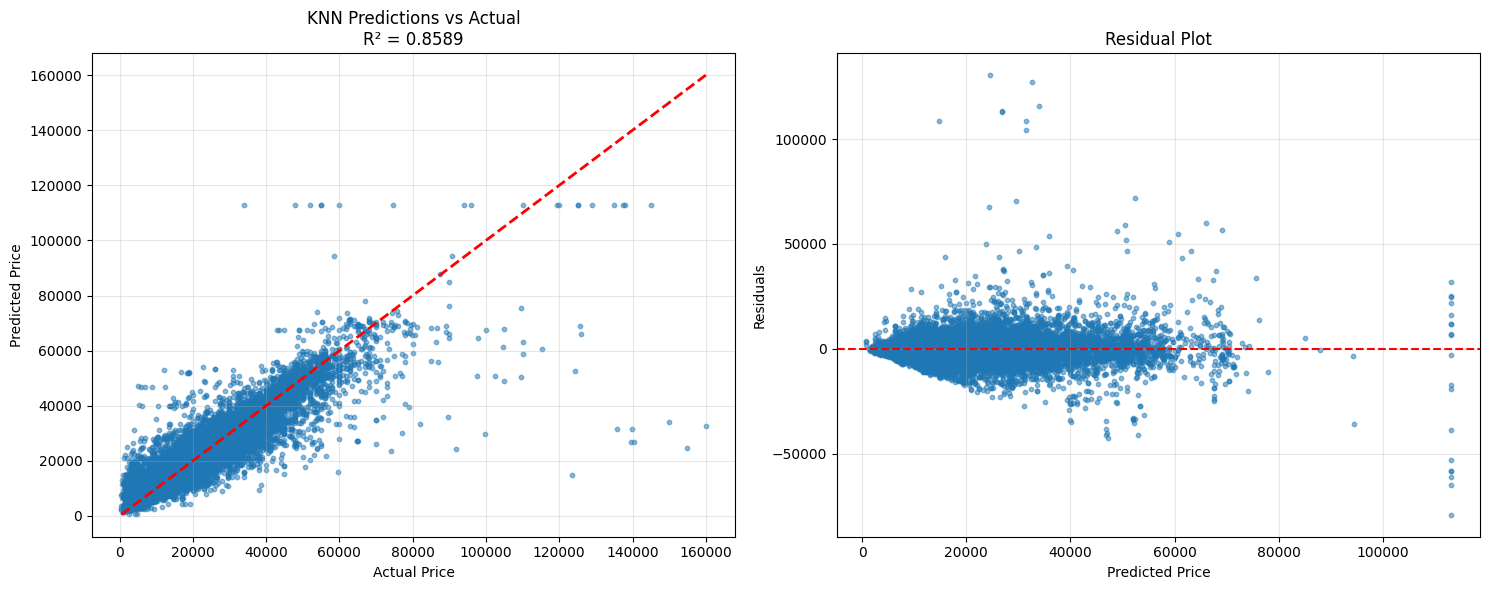

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Predictions vs Actual values
axes[0].scatter(y_val, y_pred_knn_tuned, alpha=0.5, s=10)
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'KNN Predictions vs Actual\nR² = {r2_knn_tuned:.4f}')
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
axes[1].scatter(y_pred_knn_tuned, residuals_knn_tuned, alpha=0.5, s=10)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Finding optimal K value using Elbow Method...


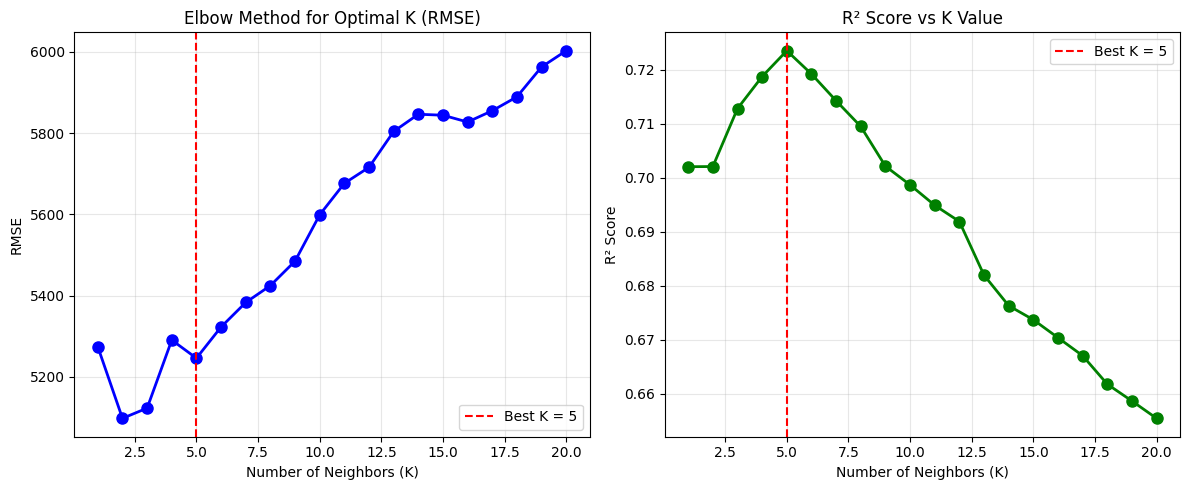

Optimal K from grid search: 5


In [14]:
print("\nFinding optimal K value using Elbow Method...")

# Test a range of K values
k_values = range(1, 21)
knn_rmse_scores = []
knn_r2_scores = []

for k in k_values:
    knn_temp = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    
    # Use cross-validation for more robust evaluation
    cv_scores = cross_val_score(knn_temp, X_sample_knn, y_sample_knn, 
                                cv=3, scoring='r2', n_jobs=-1)
    knn_r2_scores.append(cv_scores.mean())
    
    # Also calculate RMSE for elbow plot
    knn_temp.fit(choosen_features.iloc[:1000], y_train[:1000])
    y_pred_temp = knn_temp.predict(choosen_features_val.iloc[:1000])
    knn_rmse_scores.append(np.sqrt(mean_squared_error(y_val[:1000], y_pred_temp)))

# Plot elbow curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, knn_rmse_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('RMSE')
plt.title('Elbow Method for Optimal K (RMSE)')
plt.grid(True, alpha=0.3)
plt.axvline(x=grid_search_knn.best_params_['n_neighbors'], color='r', linestyle='--', 
            label=f'Best K = {grid_search_knn.best_params_["n_neighbors"]}')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(k_values, knn_r2_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('R² Score')
plt.title('R² Score vs K Value')
plt.grid(True, alpha=0.3)
plt.axvline(x=grid_search_knn.best_params_['n_neighbors'], color='r', linestyle='--',
            label=f'Best K = {grid_search_knn.best_params_["n_neighbors"]}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Optimal K from grid search: {grid_search_knn.best_params_['n_neighbors']}")


In [15]:
# Make predictions on test set
test_predictions_knn = knn_tuned.predict(choosen_features_test_data)

print(f"✓ Made KNN predictions for {len(test_predictions_knn)} test samples")
print(f"\nKNN Prediction statistics:")
print(f"  Mean: {test_predictions_knn.mean():.2f}")
print(f"  Std:  {test_predictions_knn.std():.2f}")
print(f"  Min:  {test_predictions_knn.min():.2f}")
print(f"  Max:  {test_predictions_knn.max():.2f}")

✓ Made KNN predictions for 32567 test samples

KNN Prediction statistics:
  Mean: 16892.22
  Std:  9032.29
  Min:  811.30
  Max:  112989.00


In [ ]:
#FEATURE SCALING ANALYSIS FOR KNN 

print("\n" + "="*60)
print("FEATURE SCALING ANALYSIS")
print("="*60)

# Import necessary modules
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# KNN is sensitive to feature scaling. Let's check if scaling helps
scaler = StandardScaler()
chosen_features_scaled = scaler.fit_transform(choosen_features)
chosen_features_val_scaled = scaler.transform(choosen_features_val)

# Train KNN on scaled features
knn_scaled = KNeighborsRegressor(**grid_search_knn.best_params_, n_jobs=-1)
knn_scaled.fit(chosen_features_scaled, y_train)

# Predict on scaled validation set
y_pred_knn_scaled = knn_scaled.predict(chosen_features_val_scaled)
r2_knn_scaled = r2_score(y_val, y_pred_knn_scaled)
rmse_knn_scaled = np.sqrt(mean_squared_error(y_val, y_pred_knn_scaled))

print(f"KNN without scaling: R² = {r2_knn_tuned:.4f}, RMSE = {rmse_knn_tuned:.2f}")
print(f"KNN with scaling:    R² = {r2_knn_scaled:.4f}, RMSE = {rmse_knn_scaled:.2f}")

if r2_knn_scaled > r2_knn_tuned:
    improvement_abs = r2_knn_scaled - r2_knn_tuned
    improvement_pct = (improvement_abs / r2_knn_tuned) * 100
    rmse_improvement = rmse_knn_tuned - rmse_knn_scaled
    
    print(f"\n Feature scaling improved performance!")
    print(f"   R² improvement: +{improvement_abs:.4f} ({improvement_pct:.2f}%)")
    print(f"   RMSE improvement: -{rmse_improvement:.2f}")
    
    # Create and use pipeline for final model
    print(f"\nCreating final KNN model with scaling pipeline...")
    knn_tuned = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(**grid_search_knn.best_params_, n_jobs=-1))
    ])
    
    # Retrain on full data with pipeline
    knn_tuned.fit(choosen_features, y_train)
    print(" Final KNN model with scaling pipeline trained!")
    
    # Update predictions with pipeline
    y_pred_knn_tuned = knn_tuned.predict(choosen_features_val)
    r2_knn_tuned = r2_score(y_val, y_pred_knn_tuned)
    rmse_knn_tuned = np.sqrt(mean_squared_error(y_val, y_pred_knn_tuned))
    
else:
    print("\n Feature scaling did not improve performance")
    print(" Keeping original unscaled model")



FEATURE SCALING ANALYSIS
KNN without scaling: R² = 0.8589, RMSE = 3675.14
KNN with scaling:    R² = 0.8942, RMSE = 3182.37

✅ Feature scaling improved performance!
   R² improvement: +0.0353 (4.11%)
   RMSE improvement: -492.77

Creating final KNN model with scaling pipeline...
✓ Final KNN model with scaling pipeline trained!


In [23]:


#FINAL PREDICTIONS WITH SCALED KNN


print("\n" + "="*60)
print("MAKING FINAL PREDICTIONS WITH TUNED KNN (WITH SCALING)")
print("="*60)

# Make predictions on test set
if isinstance(knn_tuned, Pipeline):
    # If using pipeline, it will automatically scale the features
    test_predictions_knn = knn_tuned.predict(choosen_features_test_data)
else:
    # If not using pipeline, scale manually
    chosen_features_test_scaled = scaler.transform(choosen_features_test_data)
    test_predictions_knn = knn_tuned.predict(chosen_features_test_scaled)

print(f"✓ Made KNN predictions for {len(test_predictions_knn)} test samples")
print(f"\nKNN Prediction statistics:")
print(f"  Mean: {test_predictions_knn.mean():.2f}")
print(f"  Std:  {test_predictions_knn.std():.2f}")
print(f"  Min:  {test_predictions_knn.min():.2f}")
print(f"  Max:  {test_predictions_knn.max():.2f}")

# Display what type of model we're using
if isinstance(knn_tuned, Pipeline):
    print(f"\nModel type: KNN with StandardScaler pipeline")
    print(f"Pipeline steps: {[step[0] for step in knn_tuned.steps]}")
else:
    print(f"\nModel type: KNN without scaling")


MAKING FINAL PREDICTIONS WITH TUNED KNN (WITH SCALING)
✓ Made KNN predictions for 32567 test samples

KNN Prediction statistics:
  Mean: 16858.03
  Std:  9122.51
  Min:  1287.69
  Max:  108214.55

Model type: KNN with StandardScaler pipeline
Pipeline steps: ['scaler', 'knn']
